---
title: "Onset of chaos in particle-core model of halo formation"
author: "Austin Hoover"
date: 2026-07-21
categories:
  - accelerators
  - chaos
bibliography: references.bib
csl: aps.csl
format:
  html:
    fig-dpi: 500
---

In [1]:
#| echo: false
import argparse

import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import matplotlib.animation as animation

plt.style.use("style.mplstyle")

Wangler et al. @wangler_1998_particle used a particle-core model to study halo formation in continuous-focusing channels. Start with an equipartitioned KV distribution with emittance $\varepsilon$ in each plane. In a attice with wavenumber $k_0$, the beam radius $R$ evolves as

$$
R'' + k_0^2 R - \frac{Q}{R} - \frac{\varepsilon^2}{R^3} = 0 .
$$

A stationary solution exists when $R'' = R' = 0$ at radius $R_0$:

$$
R_0 = (\varepsilon / k_0) \left[ u + \sqrt{1 + u} \right] ,
$$

where $u = Q / (2 \varepsilon k_0)$. 

The equation of motion for a particle on the $x$ axis is:

$$
x'' + k_0^2 x = 
\begin{cases}
  Q x / R^2, & x \le R,\\
  Q / x, &  x \ge R .
\end{cases} 
$$

Particles inside the beam see a linear field and perform harmonic oscillations at the *depressed* frequency $k^2 = k_0^2 - Q / R^2$, while particles outside the beam see a nonlinear force that decays as $1 / x$. The nonlinear force creates a continuous frequency shift, approaching the *undepressed* frequency $k_0$ at large $x$.

Here's an implementation of the ODE system in Python. For convenience, we work in dimensionless coordinates $s \rightarrow k_0 s$ and $R \rightarrow R / R_0$:

\begin{align}
R'' &= -R + \frac{\eta^2}{R^3} + \frac{1 - \eta^2}{R} , \\
x'' &= -x + (1 - \eta^2) F(x) \\
F(x) &= 
\begin{cases}
    x / {R^2} & |x| \leq R , \\
    1 / x     & |x| > R ,
\end{cases}
\end{align}

where $\eta = k / k_0 = \sqrt{1 + u^2} - u$ is the tune depression ratio within the beam at the equilibrium radius.

In [2]:
import numpy as np
import scipy.integrate


def ode_system(t: float, v: np.ndarray, eta: float) -> np.ndarray:
    """ODE system for 1D particle-core model in continuous linear focusing.

    Args:
        t: Dimensionless time coordinate.
            t = s * k0, where s is distance and k0 is lattice wavenumber.
        v: Vector of envelope and particle states.
            v[0] = Envelope radius R (scaled by equilibrium radius R0).
            v[1] = dR/dt.
            v[2] = particle x (scaled by R0).
            v[3] = dx/dt.
            ...
        eta: Tune depression ratio k / k0.

    Returns:
        dv/dt
    """
    r, rp, x, xp = v

    f_sc = 0.0
    if abs(x) <= r:
        f_sc = x / r**2
    else:
        f_sc = 1.0 / x

    vp = np.zeros_like(v)
    vp[0] = rp
    vp[1] = -r + (eta**2 / r**3) + ((1.0 - eta**2) / r)
    vp[2] = xp
    vp[3] = -x + (1.0 - eta**2) * f_sc
    return vp

The following function tracks a set of test particles, returning the coordinates vs. time. We use `scipy.integrate.solve_ivp` with the `LSODA` method to integrate the ODE.

In [3]:
def track(
    envelope: np.ndarray,
    particle: np.ndarray,
    eta: float,
    t_max: float,
    t_steps: float,
) -> dict[str, np.ndarray]:
    """Track particle-core system.

    Args:
        envelope: Initial envelope r and dr/dt.
        particles: Initial particle x and dx/dt coordinates, shape (n, 2).
        eta: Tune depression ratio.
        t_max: Evolution time.
        t_steps: Number of evaluation points along t axis.
    Returns:
        history: Dictionary with the following keys:
            - "t": time
            - "r": envelope r, shape (t_steps + 1).
            - "rp": envelope dr/dt, shape (t_steps + 1).
            - "particles": particle coordinates, shape (t_steps + 1, n, 2).
    """
    solutions = []
    for particle in particles:
        solution = scipy.integrate.solve_ivp(
            ode_system,
            t_span=(0.0, t_max),
            t_eval=np.linspace(0.0, t_max, t_steps + 1),
            y0=np.hstack([envelope, particle]),
            args=(eta,),
            method="LSODA",
            rtol=1e-8,
            atol=1e-8,
        )
        solutions.append(solution)

    history = {}
    history["t"] = solution.t
    history["r"] = solution.y[0]
    history["rp"] = solution.y[1]
    history["particles"] = np.zeros((t_steps + 1, *particles.shape))
    for index, solution in enumerate(solutions):
        history["particles"][:, index, :] = solution.y[2:].T
    return history

## Matched core

Let's track two particles: one inside and one outside the beam.

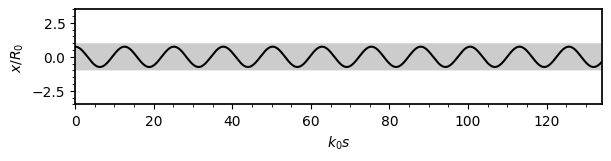

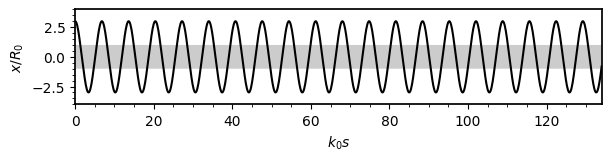

In [4]:
#| code-fold: true
import matplotlib.pyplot as plt

envelope = np.array([1.0, 0.0])
particles = np.array([[0.748, 0.0], [3.0, 0.0]])
history = track(envelope, particles, eta=0.5, t_max=134.0, t_steps=1000)

fig, ax = plt.subplots(figsize=(6.0, 1.5))
ax.fill_between(history["t"], -history["r"], +history["r"], color="black", alpha=0.2, ec="none")
ax.plot(history["t"], history["particles"][:, 0, 0], color="black")
ax.set_ylim(-3.5, 3.5)
ax.set_xlim(0.0, history["t"][-1])
ax.set_xlabel(r"$k_0 s$")
ax.set_ylabel(r"$x / R_0$")
plt.show()

fig, ax = plt.subplots(figsize=(6.0, 1.5))
ax.fill_between(history["t"], -history["r"], +history["r"], color="black", alpha=0.2, ec="none")
ax.plot(history["t"], history["particles"][:, 1, 0], color="black")
ax.set_ylim(-4.0, 4.0)
ax.set_xlim(0.0, history["t"][-1])
ax.set_xlabel(r"$k_0 s$")
ax.set_ylabel(r"$x / R_0$")
plt.show()

The oscillations are stable inside the beam and are exactly sinusoidal at the depressed frequency $k = \eta k_0 = k_0 / 2$. The oscillations are also stable outside the beam, although they are not *exactly* sinusoidal because of the frequency shift during passage through the beam. To see this, we can plot the orbits in $x$-$x'$ phase space.

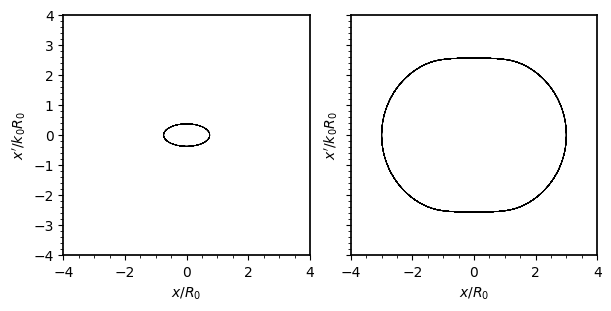

In [5]:
#| code-fold: true
fig, axs = plt.subplots(figsize=(6.0, 3.0), ncols=2, sharex=True, sharey=True)
for index, ax in enumerate(axs):
    ax.plot(history["particles"][:, index, 0], history["particles"][:, index, 1], color="black", lw=0.5)
    ax.set_xlabel(r"$x / R_0$")
    ax.set_ylabel(r"$x' / k_0 R_0$")
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-4.0, 4.0)
plt.show()

The oscillations slow down inside the beam, flattening the phase space ellipse in the range $|x| < R_0$.

## Mismatched core

If $R$ deviates from $R_0$, the core will perform "breathing mode" oscillations $R(s) = R_0 (1 + \sin(k_+ s))$ at frequency $k_+$. If a particle wanders outside the core, its frequency will decrease and eventually approach half the core oscillation frequency. This is a resonance condition that can drive particles to much larger amplitudes. (Strictly speaking, particles in the KV distribution will never exit the core, but they can do so within our particle-core model.)

To see this effect, let's track three particles---one far inside the core, one far outside the core, and one at the core boundary.

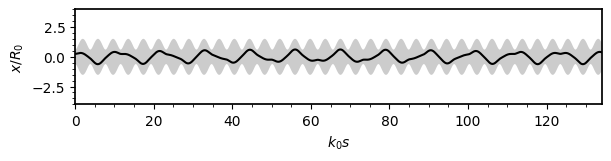

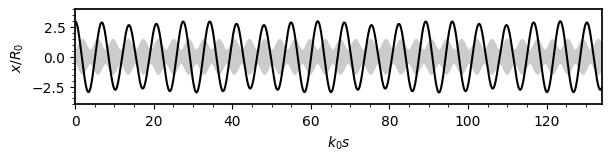

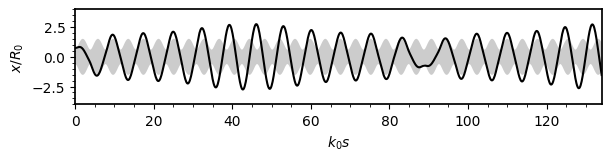

In [13]:
#| code-fold: true
envelope = np.array([0.6095, 0.0])
particles = np.array([[0.25, 0.0], [3.0, 0.0], [0.748, 0.0]])
history = track(envelope, particles, eta=0.5, t_max=134.0, t_steps=1000)

for index in range(particles.shape[0]):
    fig, ax = plt.subplots(figsize=(6.0, 1.5))
    ax.fill_between(history["t"], -history["r"], +history["r"], color="black", alpha=0.2, ec="none")
    ax.plot(history["t"], history["particles"][:, index, 0], color="black")
    ax.set_ylim(-4.0, 4.0)
    ax.set_xlim(0.0, history["t"][-1])
    ax.set_xlabel(r"$k_0 s$")
    ax.set_ylabel(r"$x / R_0$")
    plt.show()

Here are the corresponding phase space orbits:

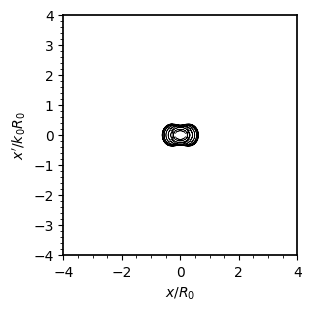

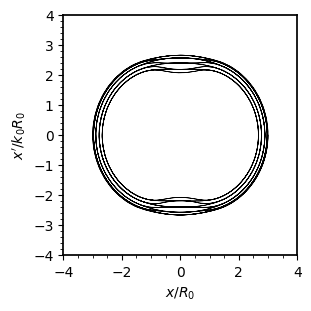

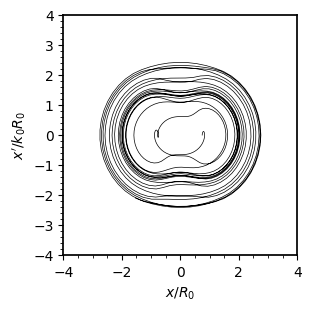

In [14]:
#| code-fold: true
for index in range(particles.shape[0]):
    fig, ax = plt.subplots(figsize=(3.0, 3.0))
    ax.plot(history["particles"][:, index, 0], history["particles"][:, index, 1], color="black", lw=0.5)
    ax.set_xlabel(r"$x / R_0$")
    ax.set_ylabel(r"$x' / k_0 R_0$")
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-4.0, 4.0)
    plt.show()

The smallest amplitude particle stays inside the core, but it's trajectory now has multiple frequency components. This is expected because the equation of motion within the core is $x'' + \kappa(s) x = 0$, where $\kappa(s)$ is some function of $s$ determined by the oscillating beam radius. This is an example of [Hill's equation](../2021-01-21-parametric-oscillators), which admits *pseudo-harmonic* solutions of the form $x(s) = A(s) \sin(\psi(s) + \psi_0)$. There is a flow of energy to/from the particle, but it always sees a linear force and its oscillations remain low-amplitude.

The particle far outside the core performs more-or-less harmonic oscillations at the undepressed frequency $k_0$. This particle receives an impulse as it crosses the beam, but the effect is not much different than when the core was matched.

The particle near the beam edge has a more complicated behavior, slowly drifting from inside to outside the core (and back). This frequency of this particle is near half the core oscillation frequency and is therefore driven through parametric resonance into the halo. This animation helps to untangle the trajectory:

In [19]:
#| code-fold: true
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Setup figure
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_xlabel(r"$x / R_0$")
ax.set_ylabel(r"$x' / k_0 R_0$")
ax.set_xlim(-4.0, 4.0)
ax.set_ylim(-4.0, 4.0)
plt.close()

# Create artists
points = history["particles"][:, 2, :]
point = ax.scatter([], [], color="black", marker=".", lw=0)
trail, = ax.plot([], [], color="black", alpha=0.3, lw=0.5, ls="-")
annotation = ax.annotate(r"$t = 0.0$", xy=(0.04, 0.90), xycoords="axes fraction", fontsize="small")

# Create animation
stride = 5
nframes = points.shape[0] // stride

def update(frame):
    i = frame * stride
    annotation.set_text(r"$t = {:0.2f}$".format(history["t"][i]))
    trail.set_data(points[:i, 0], points[:i, 1])
    point.set_offsets(points[i])
    return point, trail

anim = FuncAnimation(fig, update, frames=nframes, interval=80, blit=True)
HTML(anim.to_jshtml())

## Stroboscopic plots

We can simplify things quite a bit using *stroboscopic* plots. Instead of plotting the continuous-time evolution, we plot the system after each period of the core oscillations. The core oscillation wavenumber is $k_+$, which is approximately $k_+^2 = 2 k_0^2 + k^2$. But this formula was derived assuming small-amplitude oscillations and gives slightly different results than the integrated ODE. So here I use the `events` argument in `scipy.integrate.solve_ivp`. An "event" is a function that crosses zero; in our case we want $R' = 0$ at the core minima.

In [9]:
def track_strobe(
    envelope: np.ndarray,
    particles: np.ndarray,
    eta: float,
    periods: int,
    phase: str = "min",
) -> dict[str, np.ndarray]:
    """Track particle-core system - evaluate at minima of core radius.

    Args:
        envelope: Initial envelope r and dr/dt.
        particles: Initial particle x and dx/dt coordinates, shape (n, 2).
        eta: Tune depression ratio.
        periods: Number of envelope oscillation periods (approximate).
        phase: Whether to evaluate system at minimum or maximum beam size {"min", "max"}.
            Uses `events` parameter of `scipy.integrate.solve_ivp` to determine
            evaluation points rather than setting integration period. (Accounts for
            slight differences from theoretical envelope oscillation period.)
    Returns:
        history: Dictionary with the following keys:
            - "t": time
            - "r": envelope r, shape (t_steps + 1).
            - "rp": envelope dr/dt, shape (t_steps + 1).
            - "particles": particle coordinates, shape (t_steps + 1, n, 2).
    """

    def event_func(t: float, y: np.ndarray, eta: float) -> float:
        return y[1] if phase == "min" else -y[1]

    event_func.direction = 1

    wavenumber = np.sqrt(2.0 * (1.0 + eta**2))  # breathing mode (approximate)
    wavelength = 2.0 * np.pi / wavenumber
    t_max = periods * wavelength

    envelope = np.copy(envelope)
    if envelope[0] == 1.0:
        envelope[0] += 0.01

    solutions = []
    for particle in particles:
        solution = scipy.integrate.solve_ivp(
            ode_system,
            t_span=(0.0, t_max),
            y0=np.hstack([envelope, particle]),
            args=(eta,),
            events=event_func,
            method="LSODA",
            rtol=1e-8,
            atol=1e-8,
        )
        solutions.append(solution)

    history = {}
    history["t"] = solution.t_events[0]
    history["r"] = solution.y_events[0][:, 0]
    history["rp"] = solution.y_events[0][:, 1]
    history["particles"] = np.zeros((solution.y_events[0].shape[0], particles.shape[0], particles.shape[1]))
    for index, solution in enumerate(solutions):
        history["particles"][:, index, :] = solution.y_events[0][:, 2:]
    return history

Let's track the same three particles for 500 core oscillation periods and create a stroboscopic plot for each.

In [10]:
history_strobe = track_strobe(envelope, particles, eta=0.5, periods=500)

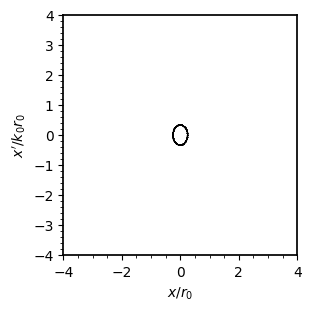

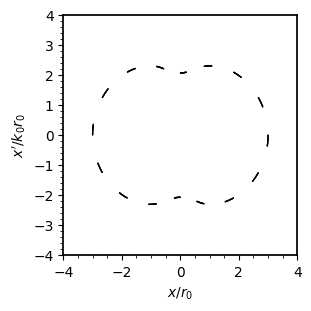

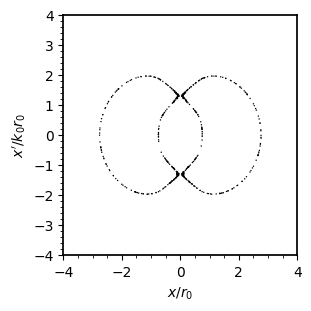

In [11]:
#| code-fold: true
for index in range(particles.shape[0]):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(
        history_strobe["particles"][:, index, 0],
        history_strobe["particles"][:, index, 1],
        c="black",
        ec="none",
        s=1,
    )
    ax.set_xlabel(r"$x / r_0$")
    ax.set_ylabel(r"$x' / k_0 r_0$")
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-4.0, 4.0)
    plt.show()

In the first plot, the period-by-period coordinates within the core trace an *ellipse*, which is expected for periodic solutions to Hill's equation (like the turn-by-turn coordinates in a storage ring.) In the second plot, the particle far outside the core has a warped trajectory in the shape of a peanut, marking the maximum halo amplitude. Finally, in the third plot, the particle sits on a separatrix. Particles just outside the separatrix will be driven out to nearly three times the equilibrium beam radius, while particles just inside the separatrix will continue their stable oscillations inside the beam.

## Chaos

The famous "peanut diagram" is formed by tracking an array of particles (spaced along the $x$ axis) and overlaying their period-by-period trajectories. Following Wangler et al., we repeat the stroboscopic plots at varying tune depression $\eta$. (Maximum space charge occurs at $\eta = 0$.)

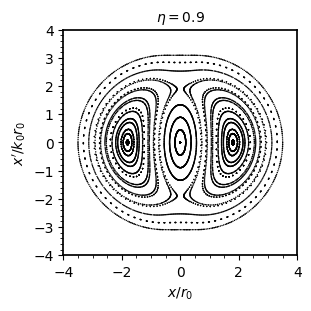

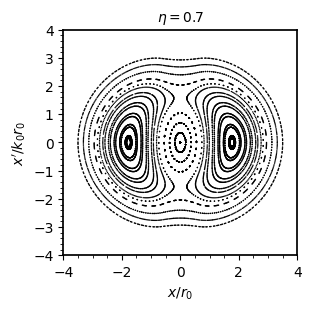

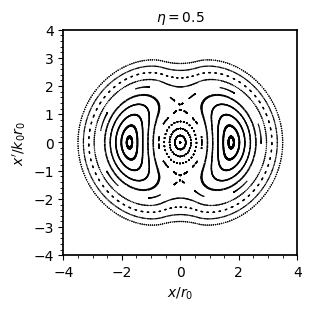

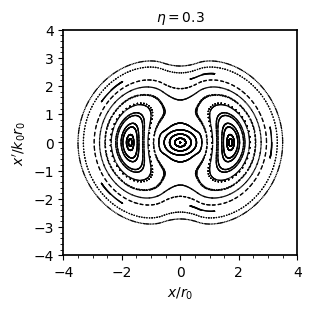

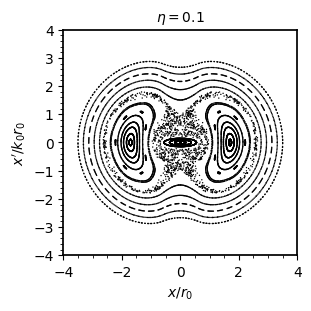

In [12]:
#| code-fold: true
particles = np.zeros((20, 2))
particles[:, 0] = np.linspace(0.0, 3.5, particles.shape[0])

for eta in [0.9, 0.7, 0.5, 0.3, 0.1]:
    history_strobe = track_strobe(envelope, particles, eta=eta, periods=500)
    
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.scatter(
        history_strobe["particles"][..., 0],
        history_strobe["particles"][..., 1],
        c="black",
        ec="none",
        s=1,
    )
    ax.set_xlabel(r"$x / r_0$")
    ax.set_ylabel(r"$x' / k_0 r_0$")
    ax.set_title(r"$\eta = {}$".format(eta))
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-4.0, 4.0)
    plt.show()

The motion becomes chaotic near the separatrix at strong tune depression, which increases the flow of particles between the core and halo regions. Batygin and Batygin @batygin_2021_chaotic have shown that the chaotic motion can have a strong dependence on the charge distribution, which was assumed to be uniform in this example.